# 02 — spaCy Baseline: Target Extraction & Moving Targets

**EarningsLens Project | Graduate Research Notebook**

This notebook implements the **Layer 1 baseline** from Cohen & Nguyen (2024) *"Moving Targets"*. The pipeline has two stages:

1. **Target Extraction** (`SpacyTargetExtractor`) — Use spaCy Named Entity Recognition (NER) and dependency parsing to identify *performance targets* in earnings call text. A performance target is a specific, quantified commitment like *"achieve 15 percent revenue growth"*.

2. **Moving Targets Computation** (`MovingTargetsComputer`) — For each firm-quarter, compare its current target set $T_{i,t}$ against the target set four quarters ago $T_{i,t-4}$. The MT score measures how many past targets the firm is *no longer mentioning*.

**The core insight:** When a firm quietly drops a previously stated target, that's a signal of management credibility. Firms that consistently drop targets underperform those that maintain them.

**Prerequisites:** Run `01_data_retrieval_exploration.ipynb` first to ensure `data/raw/transcripts_components.parquet` exists.

---
**Key paper reference:**  
Cohen, L. & Nguyen, U. (2024). *Moving Targets: Management Guidance and Firm Accountability.* NBER Working Paper.

## Setup & Imports

In [1]:
import os
import sys
import random
import textwrap
from pathlib import Path

# ── Project root on sys.path ─────────────────────────────────────────────────
# Resolve the repo root (folder that contains `src/`), whether the kernel cwd is
# the project root, `src/`, or `src/notebooks/`.
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(8):
    if (PROJECT_ROOT / "src" / "baseline").is_dir():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError(
            "Could not find project root (directory containing src/baseline). "
            "Set the Jupyter kernel working directory to the repository root, or open the notebook from that folder."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project


In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import spacy
from spacy import displacy
from tqdm.auto import tqdm

# ── EarningsLens modules ──────────────────────────────────────────────────────
from src.baseline.target_extractor import (
    SpacyTargetExtractor,
    GOAL_VERBS,
    FINANCIAL_LABELS,
    NER_LABELS,
)
from src.baseline.moving_targets import (
    MovingTargetsComputer,
    add_persistence_flags,
    _quarter_key,
    _parse_quarter_key,
)

# ── Plotting defaults ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 120})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 100)

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DIR        = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR  = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOKS_DIR  = PROJECT_ROOT / 'src' / 'notebooks'
if not NOTEBOOKS_DIR.is_dir():
    NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

print("Imports OK")
print(f"  spaCy   {spacy.__version__}")

Imports OK
  spaCy   3.8.13


---
## Section 1 — Understanding spaCy NER and the Three Extraction Criteria

### The Three Criteria for a Performance Target

Cohen & Nguyen (2024) define a *performance target* as a noun phrase that satisfies **all three** of the following conditions:

| # | Criterion | spaCy Implementation | Rationale |
|---|-----------|---------------------|----------|
| 1 | **Named Entity** with label in `{MONEY, PERCENT, PRODUCT, CARDINAL, QUANTITY}` | `doc.ents` + label filter | Ensures the NP contains a quantifiable element |
| 2 | **Numeric modifier** — a child token with `pos_=NUM` or `dep_` in `{nummod, quantmod}` | Dependency tree traversal | Ensures a specific number is attached |
| 3 | **Goal-oriented verb** governs the NP in the dependency parse | Walk head chain upward, check `lemma_` ∈ GOAL_VERBS | Distinguishes commitments from descriptions |

Example: *"We expect to achieve **15 percent revenue growth** this quarter"*
- Criterion 1: `PERCENT` entity on *15 percent*
- Criterion 2: `15` has `nummod` dependency on *percent*
- Criterion 3: head verb chain reaches *achieve* (lemma = `achieve` ∈ GOAL_VERBS)

In [3]:
# Load the spaCy model.
# en_core_web_lg (large) is recommended for accuracy.
# en_core_web_sm (small) is ~5x faster but has lower NER recall.
# If en_core_web_lg is not installed, run:
#   python -m spacy download en_core_web_lg

try:
    nlp = spacy.load('en_core_web_lg')
    print("Loaded: en_core_web_lg")
except OSError:
    print("en_core_web_lg not found, falling back to en_core_web_sm")
    nlp = spacy.load('en_core_web_sm')
    print("Loaded: en_core_web_sm")

print(f"Pipeline components: {nlp.pipe_names}")
print(f"NER labels available: {nlp.get_pipe('ner').labels[:10]} ...")

en_core_web_lg not found, falling back to en_core_web_sm
Loaded: en_core_web_sm
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
NER labels available: ('CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP') ...


In [4]:
# Process a single earnings-call-style sentence with spaCy
# and inspect the output in detail

SAMPLE_SENTENCE = (
    "We expect to achieve 15 percent revenue growth this quarter "
    "and deliver $2 billion in free cash flow by year-end."
)

doc = nlp(SAMPLE_SENTENCE)

print("Named Entities (NER):")
print("-" * 50)
for ent in doc.ents:
    flag = "✓ relevant" if ent.label_ in NER_LABELS else "  (excluded)"
    print(f"  {ent.text!r:35s}  label={ent.label_:10s}  {flag}")

print("\nNoun Chunks:")
print("-" * 50)
for chunk in doc.noun_chunks:
    print(f"  {chunk.text!r:45s}  root='{chunk.root.text}'  root_dep='{chunk.root.dep_}'")

Named Entities (NER):
--------------------------------------------------
  '15 percent'                         label=PERCENT     ✓ relevant
  'this quarter'                       label=DATE          (excluded)
  '$2 billion'                         label=MONEY       ✓ relevant
  'year-end'                           label=DATE          (excluded)

Noun Chunks:
--------------------------------------------------
  'We'                                           root='We'  root_dep='nsubj'
  '15 percent revenue growth'                    root='growth'  root_dep='dobj'
  'free cash flow'                               root='flow'  root_dep='pobj'
  'year-end'                                     root='end'  root_dep='pobj'


In [5]:
# Visualize NER entities with displacy
# This renders an HTML visualization; in Jupyter it displays inline.

# Render as HTML string (safe for all Jupyter environments)
html = displacy.render(doc, style='ent', jupyter=False)
from IPython.display import HTML
display(HTML(html))

In [6]:
# Inspect POS tags and dependency labels for every token.
# This is the most educational view — you can see exactly what
# spaCy assigns to each word before the extraction logic runs.

print(f"{'Token':20s}  {'Lemma':15s}  {'POS':8s}  {'Dep':12s}  {'Head':15s}  {'NER'}")  
print("-" * 90)
ent_lookup = {tok.i: ent.label_ for ent in doc.ents for tok in ent}
for tok in doc:
    ner = ent_lookup.get(tok.i, '')
    is_num_flag = '← NUM' if tok.pos_ == 'NUM' else ''
    is_nummod   = '← nummod' if tok.dep_ == 'nummod' else ''
    print(f"  {tok.text:18s}  {tok.lemma_:13s}  {tok.pos_:8s}  {tok.dep_:12s}  "
          f"{tok.head.text:13s}  {ner:10s}  {is_num_flag}{is_nummod}")

Token                 Lemma            POS       Dep           Head             NER
------------------------------------------------------------------------------------------
  We                  we             PRON      nsubj         expect                     
  expect              expect         VERB      ROOT          expect                     
  to                  to             PART      aux           achieve                    
  achieve             achieve        VERB      xcomp         expect                     
  15                  15             NUM       nummod        percent        PERCENT     ← NUM← nummod
  percent             percent        NOUN      compound      revenue        PERCENT     
  revenue             revenue        NOUN      compound      growth                     
  growth              growth         NOUN      dobj          achieve                    
  this                this           DET       det           quarter        DATE        
  quarter  

In [7]:
# Step-by-step walkthrough of the extraction logic on the sample sentence
# This mirrors exactly what SpacyTargetExtractor._evaluate_noun_phrase does.

print("Sentence:", SAMPLE_SENTENCE)
print("\n" + "=" * 70)
print("Walking through extraction criteria for each noun chunk:")
print("=" * 70)

for sent in doc.sents:
    ent_map = {tok.i: ent.label_ for ent in doc.ents if ent.label_ in NER_LABELS
               for tok in ent}

    for nchunk in sent.noun_chunks:
        print(f"\n  NP: {nchunk.text!r}")

        # --- Criterion 1 ---
        entity_label = None
        for tok in nchunk:
            if tok.i in ent_map:
                entity_label = ent_map[tok.i]
                break
        print(f"    Criterion 1 (NER): entity_label={entity_label!r}  "
              f"{'✓ PASS' if entity_label else '✗ FAIL'}")
        if not entity_label:
            continue

        # --- Criterion 2 ---
        numeric_value = None
        for tok in nchunk:
            for child in tok.children:
                if child.pos_ in {'NUM'} or child.dep_ in {'nummod', 'quantmod', 'num'}:
                    numeric_value = child.text
                    break
            if numeric_value:
                break
        if not numeric_value:
            for tok in nchunk:
                if tok.pos_ == 'NUM':
                    numeric_value = tok.text
                    break
        print(f"    Criterion 2 (NUM): numeric_value={numeric_value!r}  "
              f"{'✓ PASS' if numeric_value else '✗ FAIL'}")
        if not numeric_value:
            continue

        # --- Criterion 3: walk head chain looking for a goal verb ---
        root = nchunk.root
        governing_verb = None
        current = root
        visited = set()
        path = []
        while current.i not in visited:
            visited.add(current.i)
            head = current.head
            path.append(f"{current.text}→{head.text}({head.lemma_})")
            if head.pos_ in {'VERB', 'AUX'} and head.lemma_.lower() in GOAL_VERBS:
                governing_verb = head.lemma_.lower()
                break
            if head.i == current.i:
                break
            current = head

        print(f"    Criterion 3 (VERB): head_chain={' '.join(path[:4])}")
        print(f"               governing_verb={governing_verb!r}  "
              f"{'✓ PASS' if governing_verb else '✗ FAIL'}")

        if governing_verb:
            print(f"    ✅  TARGET EXTRACTED: {nchunk.text!r}")

Sentence: We expect to achieve 15 percent revenue growth this quarter and deliver $2 billion in free cash flow by year-end.

Walking through extraction criteria for each noun chunk:

  NP: 'We'
    Criterion 1 (NER): entity_label=None  ✗ FAIL

  NP: '15 percent revenue growth'
    Criterion 1 (NER): entity_label='PERCENT'  ✓ PASS
    Criterion 2 (NUM): numeric_value='15'  ✓ PASS
    Criterion 3 (VERB): head_chain=growth→achieve(achieve)
               governing_verb='achieve'  ✓ PASS
    ✅  TARGET EXTRACTED: '15 percent revenue growth'

  NP: 'free cash flow'
    Criterion 1 (NER): entity_label=None  ✗ FAIL

  NP: 'year-end'
    Criterion 1 (NER): entity_label=None  ✗ FAIL


---
## Section 2 — Single Transcript Extraction

Now we use the full `SpacyTargetExtractor` class on a real transcript. We load the components parquet file, pick one transcript, and run extraction on all its text segments.

In [8]:
# Load transcript components from data/raw/ (Dataset 1 — CIQ components; see 1a_data_retrieval.pdf)
# Files may be named transcripts_components.parquet (notebook 01) or ciq_transcripts.parquet (CIQ export).
# Optional: export EARNINGSLENS_RAW=/path/to/.../data/raw to point at another folder.
import os
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq

# How many distinct calls to pull from a huge CIQ parquet (Sections 3–6).
# Raise for larger batches (slower scan + more RAM when loading all rows for those IDs).
MAX_TRANSCRIPTS_FROM_LARGE_FILE = 1000

# Large files only: scan transcriptid + companyid + call_date and prefer transcripts that sit in
# YoY calendar-quarter pairs (same quarter, consecutive years) for the same firm — needed for
# non-empty Moving Targets in Section 7. Slower first load. False = first-N transcript IDs (often empty mt_df).
SAMPLE_TRANSCRIPTS_FOR_MT_PAIRS = True

_components_candidates = []
_ev = os.environ.get("EARNINGSLENS_RAW", "").strip()
if _ev:
    _ro = Path(_ev).expanduser().resolve()
    _components_candidates.extend(
        [_ro / "transcripts_components.parquet", _ro / "ciq_transcripts.parquet"]
    )
_components_candidates.extend(
    [
        RAW_DIR / "transcripts_components.parquet",
        RAW_DIR / "ciq_transcripts.parquet",
        PROJECT_ROOT.parent / "EarningsLens" / "data" / "raw" / "ciq_transcripts.parquet",
        PROJECT_ROOT.parent / "EarningsLens" / "data" / "raw" / "transcripts_components.parquet",
    ]
)

components_path = next((p for p in _components_candidates if p.exists()), None)

if components_path is not None:
    _pf = pq.ParquetFile(components_path)
    _nrows = _pf.metadata.num_rows
    _colnames = set(_pf.schema_arrow.names)

    _want = [
        "transcriptid",
        "companyname",
        "componenttypeid",
        "componentorder",
        "componenttext",
    ]
    if "companyid" in _colnames:
        _want.insert(1, "companyid")
    if "transcriptpersonname" in _colnames:
        _want.append("transcriptpersonname")
    elif "transcriptpersonid" in _colnames:
        _want.append("transcriptpersonid")
    for _c in (
        "call_date",
        "event_date",  # common in CIQ component exports when call_date is absent
        "transcriptcreationdate",
        "fiscalyear",
        "fiscalquarter",
    ):
        if _c in _colnames:
            _want.append(_c)

    _usecols = [c for c in _want if c in _colnames]

    if _nrows > 2_000_000:
        import pandas as pd

        print(
            f"Large components file ({_nrows:,} rows) — loading up to "
            f"{MAX_TRANSCRIPTS_FROM_LARGE_FILE} distinct transcriptid values "
            f"(avoid pd.read_parquet on the full table)."
        )
        _dataset = ds.dataset(components_path, format="parquet")

        _date_col = None
        for _c in ("call_date", "event_date", "transcriptcreationdate"):
            if _c in _colnames:
                _date_col = _c
                break

        _tid_list = None
        if (
            SAMPLE_TRANSCRIPTS_FOR_MT_PAIRS
            and "companyid" in _colnames
            and _date_col is not None
        ):
            print(
                f"Scanning {_pf.num_row_groups} row groups for YoY calendar-quarter pairs "
                f"(companyid + {_date_col}) — this can take a few minutes…"
            )
            # Per company: (calendar year, quarter) -> one transcriptid (last wins within scan)
            _cq_by_cid: dict = {}
            for _rgi in range(_pf.num_row_groups):
                _tbl = _pf.read_row_group(
                    _rgi, columns=["transcriptid", "companyid", _date_col]
                ).to_pandas()
                _tbl = _tbl.dropna(subset=["transcriptid", "companyid", _date_col])
                if len(_tbl) == 0:
                    continue
                _tbl = _tbl.drop_duplicates(subset=["transcriptid"], keep="first")
                _cdt = pd.to_datetime(_tbl[_date_col], errors="coerce")
                _tbl = _tbl.assign(_fy=_cdt.dt.year, _fq=_cdt.dt.quarter)
                _tbl = _tbl.dropna(subset=["_fy", "_fq"])
                _tids = _tbl["transcriptid"].to_numpy()
                _cids = _tbl["companyid"].to_numpy()
                _fya = _tbl["_fy"].to_numpy(dtype="int64", copy=False)
                _fqa = _tbl["_fq"].to_numpy(dtype="int64", copy=False)
                for _i in range(len(_tbl)):
                    _cq_by_cid.setdefault(str(_cids[_i]), {})[
                        (int(_fya[_i]), int(_fqa[_i]))
                    ] = _tids[_i]

            # Add whole YoY pairs only so we do not drop one leg of (t) vs (t-1 year same Q) and break MT.
            _used: set = set()
            for _cidk, _qmap in _cq_by_cid.items():
                for (_fy, _fq), _tid in _qmap.items():
                    if (_fy - 1, _fq) not in _qmap:
                        continue
                    _lag = _qmap[(_fy - 1, _fq)]
                    _need = 2 - (_tid in _used) - (_lag in _used)
                    if _need <= 0:
                        continue
                    if len(_used) + _need > MAX_TRANSCRIPTS_FROM_LARGE_FILE:
                        continue
                    _used.add(_tid)
                    _used.add(_lag)

            _tid_list = sorted(_used)
            _n_cos = len(_cq_by_cid)
            _n_pair_tids = len(_tid_list)
            print(
                f"YoY-pair scan: {_n_cos:,} companies with ≥1 dated call; "
                f"{_n_pair_tids:,} transcript IDs kept as full YoY pairs (cap {MAX_TRANSCRIPTS_FROM_LARGE_FILE})."
            )
            if len(_tid_list) == 0:
                print(
                    "No YoY pairs found in scan — falling back to first-N transcript IDs (Section 7 MT may stay empty)."
                )

        if _tid_list is None or len(_tid_list) == 0:
            _seen_tid = set()
            _tid_list = []
            for _rgi in range(_pf.num_row_groups):
                _tc = _pf.read_row_group(_rgi, columns=["transcriptid"])["transcriptid"]
                for _j in range(len(_tc)):
                    _v = _tc[_j].as_py()
                    if _v not in _seen_tid:
                        _seen_tid.add(_v)
                        _tid_list.append(_v)
                    if len(_tid_list) >= MAX_TRANSCRIPTS_FROM_LARGE_FILE:
                        break
                if len(_tid_list) >= MAX_TRANSCRIPTS_FROM_LARGE_FILE:
                    break

        _tid_arr = pa.array(_tid_list)
        components_df = (
            _dataset.to_table(filter=ds.field("transcriptid").isin(_tid_arr), columns=_usecols)
            .to_pandas()
        )
        print(
            f"Loaded {len(_tid_list)} transcript id(s) → {components_df.shape[0]:,} component rows "
            f"(unique transcripts in frame: {components_df['transcriptid'].nunique()})."
        )
    else:
        components_df = pd.read_parquet(components_path, columns=_usecols)

    if "transcriptpersonname" not in components_df.columns and "transcriptpersonid" in components_df.columns:
        components_df = components_df.copy()
        components_df["transcriptpersonname"] = components_df["transcriptpersonid"].astype(str)

    # Section 7 needs a call timestamp: some exports only have event_date / transcriptcreationdate
    if "call_date" not in components_df.columns:
        for _alt in ("event_date", "transcriptcreationdate"):
            if _alt in components_df.columns:
                components_df = components_df.copy()
                components_df["call_date"] = components_df[_alt]
                break

    print(f"Loaded transcript components: {components_df.shape} from {components_path}")
    display(components_df.head(3))
else:
    # Fallback: use the example synthetic transcript from the source code
    print("Components file not found in any candidate path (see cell comments).")
    print("Using synthetic example transcript for demonstration.")
    components_df = pd.DataFrame([
        {'transcriptid': 9999, 'companyname': 'DEMO CORP', 'componenttypeid': 2,
         'componentorder': 1, 'transcriptpersonname': 'CEO',
         'componenttext': (
             "We expect to achieve revenue growth of 15 percent this fiscal year. "
             "Our goal is to deliver $2 billion in free cash flow. "
             "Management is committed to maintaining a 40 percent gross margin. "
             "We plan to increase our market share by 5 percentage points."
         )},
        {'transcriptid': 9999, 'companyname': 'DEMO CORP', 'componenttypeid': 4,
         'componentorder': 2, 'transcriptpersonname': 'CFO',
         'componenttext': (
             "We are targeting 20 percent EBITDA margins by the end of Q4. "
             "The company aims to generate $500 million in operating income. "
             "We will hit our earnings per share target of $3.50. "
             "We expect to sustain double-digit revenue growth through 2025."
         )},
        {'transcriptid': 9999, 'companyname': 'DEMO CORP', 'componenttypeid': 3,
         'componentorder': 3, 'transcriptpersonname': 'Analyst',
         'componenttext': (
             "Can you elaborate on the 15 percent growth assumption? "
             "And do you still expect $2 billion in cash flow given the macro?"
         )},
    ])

Large components file (68,323,879 rows) — loading up to 1000 distinct transcriptid values (avoid pd.read_parquet on the full table).
Scanning 104 row groups for YoY calendar-quarter pairs (companyid + call_date) — this can take a few minutes…
YoY-pair scan: 17,810 companies with ≥1 dated call; 999 transcript IDs kept as full YoY pairs (cap 1000).
Loaded 999 transcript id(s) → 51,395 component rows (unique transcripts in frame: 999).
Loaded transcript components: (51395, 10) from /Users/tiantian/Downloads/CU Material/S3/5293/Project/EarningsLens/data/raw/ciq_transcripts.parquet


,transcriptid,companyid,companyname,componenttypeid,componentorder,componenttext,transcriptpersonid,call_date,event_date,transcriptpersonname
0,52541.0,378088.0,Shenandoah Telecommunications Company,4,51,"Well, Sprint would not sell because we are Sprint there. There’s nothing that precludes Clearwir...",61923,2010-03-04,2010-03-04,61923
1,53838.0,365602.0,"FARO Technologies, Inc.",2,4,"Thanks, Keith. So as expected, 2009 was an extremely difficult year. The first three quarters of...",127190,2010-03-17,2010-02-25,127190
2,53838.0,365602.0,"FARO Technologies, Inc.",3,8,"And can we talk a little bit about the gross margin situation? I mean, would have thought it wou...",102782,2010-03-17,2010-02-25,102782


In [9]:
# Pick one transcript to work with
COMPONENT_LABELS = {2: 'Presentation', 3: 'Analyst Q', 4: 'Mgmt Answer'}

# Select the first transcript ID in the dataset
example_tid = components_df['transcriptid'].iloc[0]
one_transcript_df = components_df[components_df['transcriptid'] == example_tid].copy()

# Get company name if available
company_name = ''
if 'companyname' in one_transcript_df.columns:
    company_name = one_transcript_df['companyname'].iloc[0]

print(f"Transcript ID: {example_tid}")
print(f"Company:       {company_name}")
print(f"Components:    {len(one_transcript_df)}")
print(f"Total text chars: {one_transcript_df['componenttext'].str.len().sum():,}")
print()
for _, row in one_transcript_df.iterrows():
    label = COMPONENT_LABELS.get(row['componenttypeid'], 'Other')
    print(f"  [{label}] speaker={row.get('transcriptpersonname', '?')!r}  "
          f"len={len(row.get('componenttext','') or ''):,} chars")

Transcript ID: 52541.0
Company:       Shenandoah Telecommunications Company
Components:    68
Total text chars: 40,743

  [Mgmt Answer] speaker='61923'  len=617 chars
  [Analyst Q] speaker='74542'  len=693 chars
  [Analyst Q] speaker='74542'  len=639 chars
  [Analyst Q] speaker='74542'  len=17 chars
  [Analyst Q] speaker='138868'  len=14 chars
  [Mgmt Answer] speaker='122956'  len=314 chars
  [Analyst Q] speaker='8312'  len=204 chars
  [Mgmt Answer] speaker='61923'  len=2,295 chars
  [Mgmt Answer] speaker='61923'  len=1,394 chars
  [Mgmt Answer] speaker='61922'  len=193 chars
  [Mgmt Answer] speaker='61922'  len=225 chars
  [Presentation] speaker='122956'  len=4,421 chars
  [Analyst Q] speaker='8312'  len=403 chars
  [Analyst Q] speaker='8312'  len=262 chars
  [Analyst Q] speaker='74542'  len=21 chars
  [Mgmt Answer] speaker='61923'  len=954 chars
  [Mgmt Answer] speaker='61922'  len=86 chars
  [Analyst Q] speaker='8312'  len=24 chars
  [Analyst Q] speaker='8312'  len=203 chars
  [Anal

In [10]:
# Instantiate the extractor and run on the single transcript
extractor = SpacyTargetExtractor(model_name='en_core_web_lg')

# Build the list-of-dicts format expected by extract_from_transcript
transcript_components = [
    {
        'component_type': row['componenttypeid'],
        'text': row.get('componenttext', '') or '',
    }
    for _, row in one_transcript_df.iterrows()
]

targets = extractor.extract_from_transcript(transcript_components)
targets_df = pd.DataFrame(targets)

print(f"Extracted {len(targets_df)} performance targets from transcript {example_tid}")
if len(targets_df) > 0:
    display(targets_df.head(10))

Extracted 8 performance targets from transcript 52541.0


,target_text,entity_label,numeric_value,governing_verb,is_financial,sentence,component_type
0,1.9%,PERCENT,1.9,increase,True,Churn increased just slightly from 1.9% in the fourth quarter of 2008 to 2% in the fourth quarte...,2
1,to 2%,PERCENT,to,increase,True,Churn increased just slightly from 1.9% in the fourth quarter of 2008 to 2% in the fourth quarte...,2
2,3G,CARDINAL,3,expect,False,"The extension of the Philly market will include Harrisburg and York, Pennsylvania, and the expec...",4
3,4G data cards,CARDINAL,4,expect,False,"The extension of the Philly market will include Harrisburg and York, Pennsylvania, and the expec...",4
4,16%,PERCENT,16,grow,True,"As you can see on slide 13, our PCS customers have grown at an annual compound rate of 16% over ...",2
5,8%,PERCENT,8,grow,True,"Total billed revenue grew by 8%, but net revenue grew by 11%.",2
6,11%,PERCENT,11,grow,True,"Total billed revenue grew by 8%, but net revenue grew by 11%.",2
7,the 1.1 million drop,CARDINAL,1.1,expect,False,This increase is expected to compensate for a significant percentage of the 1.1 million drop in ...,2


In [11]:
# Examine a few individual targets in detail
if len(targets_df) > 0:
    print("Detailed view of extracted targets:")
    print("=" * 80)
    for i, row in targets_df.head(5).iterrows():
        print(f"\n  Target #{i+1}: {row['target_text']!r}")
        print(f"    Entity label:    {row['entity_label']}")
        print(f"    Numeric value:   {row['numeric_value']}")
        print(f"    Governing verb:  {row['governing_verb']}")
        print(f"    Is financial:    {row['is_financial']}")
        comp_label = COMPONENT_LABELS.get(row['component_type'], '?')
        print(f"    Component type:  {comp_label} ({row['component_type']})")
        # Show the source sentence (truncated)
        src = row.get('sentence', '') or ''
        print(f"    Source sentence: {src[:120]}{'...' if len(src)>120 else ''}")
else:
    print("No targets extracted — check that the transcript has earnings content.")

Detailed view of extracted targets:

  Target #1: '1.9%'
    Entity label:    PERCENT
    Numeric value:   1.9
    Governing verb:  increase
    Is financial:    True
    Component type:  Presentation (2)
    Source sentence: Churn increased just slightly from 1.9% in the fourth quarter of 2008 to 2% in the fourth quarter 2009.

  Target #2: 'to 2%'
    Entity label:    PERCENT
    Numeric value:   to
    Governing verb:  increase
    Is financial:    True
    Component type:  Presentation (2)
    Source sentence: Churn increased just slightly from 1.9% in the fourth quarter of 2008 to 2% in the fourth quarter 2009.

  Target #3: '3G'
    Entity label:    CARDINAL
    Numeric value:   3
    Governing verb:  expect
    Is financial:    False
    Component type:  Mgmt Answer (4)
    Source sentence: The extension of the Philly market will include Harrisburg and York, Pennsylvania, and the expected date for the launch ...

  Target #4: '4G data cards'
    Entity label:    CARDINAL
    Num

---
## Section 3 — Goal Verb Analysis

The goal verb list is a critical modeling choice. It defines what counts as a *forward-looking commitment* vs. a *backward-looking description*.

- **Included:** *achieve, target, maintain, expect, deliver, reach, sustain, exceed, grow, generate, drive, hit, attain, improve, increase*
- **Why *describe* is excluded:** "our revenue grew 10%" is a historical statement, not a commitment.
- **Why *hope* is excluded:** too weak — not a quantified corporate commitment in the same sense.

In [12]:
# Display the full goal verb list with rationale
VERB_RATIONALE = {
    'achieve'  : 'Canonical commitment verb — "achieve X% growth"',
    'target'   : 'Explicit numerical target — "targeting $2B revenue"',
    'maintain' : 'Continuity commitment — "maintain 40% margins"',
    'expect'   : 'Forward guidance — "expect 15% growth" (most common)',
    'deliver'  : 'Output commitment — "deliver $1B FCF"',
    'reach'    : 'Milestone language — "reach $10B ARR"',
    'sustain'  : 'Durability commitment — "sustain double-digit growth"',
    'exceed'   : 'Above-target signal — "exceed $500M in profit"',
    'grow'     : 'Growth-rate target — "grow revenue 20%"',
    'generate' : 'Output language — "generate $300M in cash"',
    'drive'    : 'Active initiative — "drive 5% cost savings"',
    'hit'      : 'Colloquial milestone — "hit our $3.50 EPS target"',
    'attain'   : 'Formal variant of achieve',
    'improve'  : 'Directional commitment — "improve margins by 200bps"',
    'increase' : 'Magnitude commitment — "increase dividend 10%"',
}

print(f"Goal Verb List ({len(GOAL_VERBS)} verbs):")
print("=" * 70)
for verb in sorted(GOAL_VERBS):
    rationale = VERB_RATIONALE.get(verb, '')
    print(f"  {verb:12s}  {rationale}")

Goal Verb List (18 verbs):
  achieve       Canonical commitment verb — "achieve X% growth"
  aim           
  attain        Formal variant of achieve
  commit        
  deliver       Output commitment — "deliver $1B FCF"
  drive         Active initiative — "drive 5% cost savings"
  exceed        Above-target signal — "exceed $500M in profit"
  expect        Forward guidance — "expect 15% growth" (most common)
  generate      Output language — "generate $300M in cash"
  grow          Growth-rate target — "grow revenue 20%"
  hit           Colloquial milestone — "hit our $3.50 EPS target"
  improve       Directional commitment — "improve margins by 200bps"
  increase      Magnitude commitment — "increase dividend 10%"
  maintain      Continuity commitment — "maintain 40% margins"
  plan          
  reach         Milestone language — "reach $10B ARR"
  sustain       Durability commitment — "sustain double-digit growth"
  target        Explicit numerical target — "targeting $2B revenue"


In [13]:
# Process up to 30 transcripts (or however many are available) and count verb frequencies
N_SAMPLE_CAP = 30
N_SAMPLE = min(N_SAMPLE_CAP, components_df['transcriptid'].nunique())
sample_tids = components_df['transcriptid'].unique()[:N_SAMPLE]
sample_components_100 = components_df[components_df['transcriptid'].isin(sample_tids)]

verb_counts = {}
all_targets_100 = []

for tid in tqdm(sample_tids, desc=f'Extracting ({N_SAMPLE} transcripts)', unit='transcript'):
    rows = sample_components_100[sample_components_100['transcriptid'] == tid]
    comps = [
        {'component_type': r['componenttypeid'], 'text': r.get('componenttext', '') or ''}
        for _, r in rows.iterrows()
    ]
    tgts = extractor.extract_from_transcript(comps)
    for t in tgts:
        t['transcriptid'] = tid
        verb = t.get('governing_verb', 'unknown')
        verb_counts[verb] = verb_counts.get(verb, 0) + 1
    all_targets_100.extend(tgts)

print(f"\nTotal targets extracted from {N_SAMPLE} transcripts: {len(all_targets_100):,}")
print(f"Mean targets per transcript: {len(all_targets_100)/N_SAMPLE:.1f}")

Extracting (30 transcripts): 100%|██████████| 30/30 [00:29<00:00,  1.02transcript/s]


Total targets extracted from 30 transcripts: 207
Mean targets per transcript: 6.9


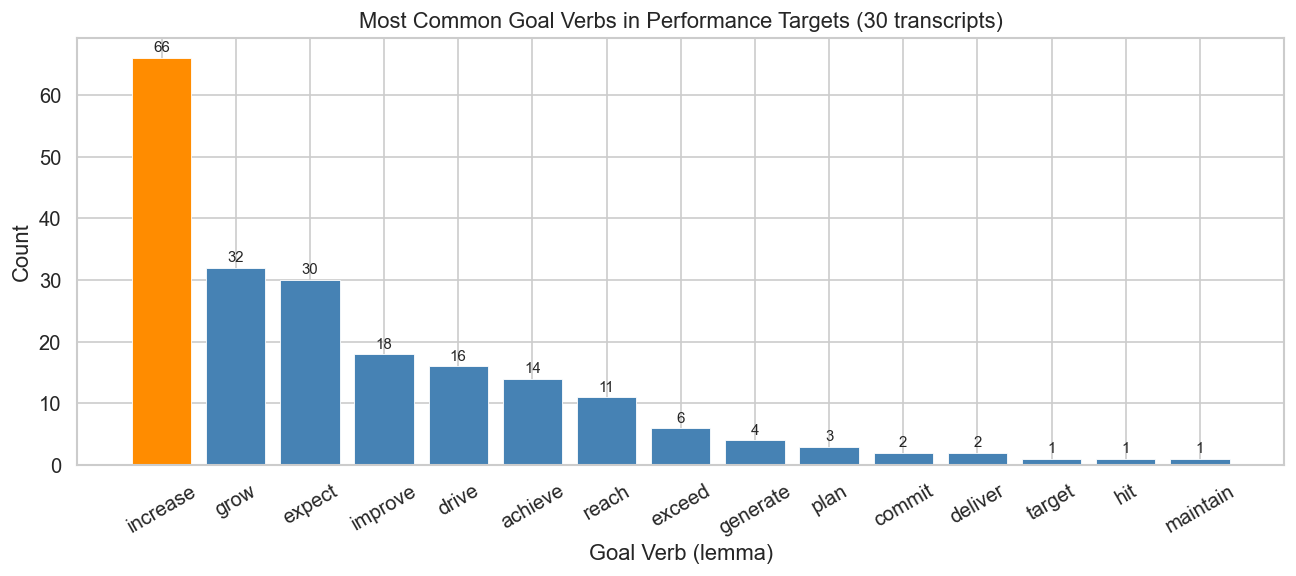


Top 5 most common verbs:
increase    66
grow        32
expect      30
improve     18
drive       16
dtype: int64

'expect' frequency as % of all targets: 14.5%


In [14]:
# Bar chart of governing verb frequencies

if verb_counts:
    verb_series = pd.Series(verb_counts).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ['steelblue' if v != verb_series.idxmax() else 'darkorange' for v in verb_series.index]
    bars = ax.bar(verb_series.index, verb_series.values, color=colors, edgecolor='white', linewidth=0.5)

    # Add value labels on top of bars
    for bar, val in zip(bars, verb_series.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Most Common Goal Verbs in Performance Targets ({N_SAMPLE} transcripts)')
    ax.set_xlabel('Goal Verb (lemma)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(NOTEBOOKS_DIR / 'nb02_verb_frequencies.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop 5 most common verbs:")
    print(verb_series.head(5))
    print(f"\n'expect' frequency as % of all targets: {verb_series.get('expect', 0)/sum(verb_counts.values()):.1%}")
else:
    print("No targets found — check that extractor is running correctly.")

---
## Section 4 — Entity Type Distribution

Not all extracted targets are financial. spaCy's NER labels give us a natural split:
- **Financial:** `MONEY` (dollar amounts) and `PERCENT` (percentage figures)
- **Non-financial:** `PRODUCT`, `CARDINAL`, `QUANTITY`

Cohen & Nguyen (2024) find that *non-financial target drops* have stronger stock return predictive power than financial ones — suggesting the market under-prices the signal embedded in strategic / operational commitments.

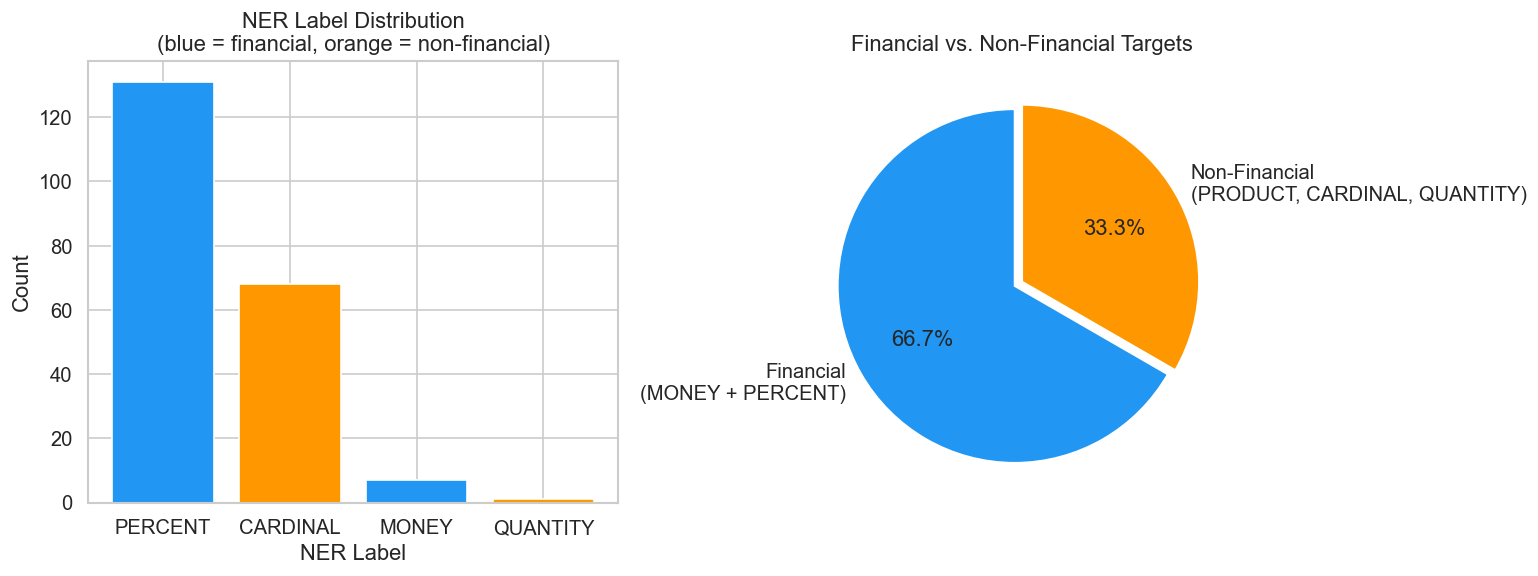


Financial targets:     138  (66.7%)
Non-financial targets: 69  (33.3%)


In [15]:
# Entity type distribution from the multi-transcript sample (same as verb analysis above)
if all_targets_100:
    sample_tgt_df = pd.DataFrame(all_targets_100)

    label_counts = sample_tgt_df['entity_label'].value_counts()
    fin_count  = sample_tgt_df['is_financial'].sum()
    nfin_count = (~sample_tgt_df['is_financial']).sum()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: NER label breakdown
    colors = ['#2196F3' if lbl in FINANCIAL_LABELS else '#FF9800' for lbl in label_counts.index]
    axes[0].bar(label_counts.index, label_counts.values, color=colors)
    axes[0].set_title('NER Label Distribution\n(blue = financial, orange = non-financial)')
    axes[0].set_xlabel('NER Label')
    axes[0].set_ylabel('Count')

    # Right: binary financial / non-financial pie
    axes[1].pie(
        [fin_count, nfin_count],
        labels=['Financial\n(MONEY + PERCENT)', 'Non-Financial\n(PRODUCT, CARDINAL, QUANTITY)'],
        colors=['#2196F3', '#FF9800'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0),
    )
    axes[1].set_title('Financial vs. Non-Financial Targets')

    plt.tight_layout()
    plt.show()

    print(f"\nFinancial targets:     {fin_count:,}  ({fin_count/len(sample_tgt_df):.1%})")
    print(f"Non-financial targets: {nfin_count:,}  ({nfin_count/len(sample_tgt_df):.1%})")
else:
    print("No sample targets available.")

---
## Section 5 — Target Normalization

Before computing Moving Targets we need to **normalize** target text so that semantically identical targets are treated as equal even if worded differently.

The `normalize_target()` method:
1. Converts to lowercase
2. Lemmatizes each token (using spaCy's `tok.lemma_`)
3. Drops leading determiners and possessives (*"the"*, *"our"*)
4. Collapses whitespace

This means *"our EBITDA margins"* and *"the EBITDA margin"* both normalize to `"ebitda margin"`, and they are treated as the **same target** in the MT computation.

In [16]:
# Demonstrate normalize_target on a variety of examples

normalization_examples = [
    # (input phrase, expected behavior)
    ("our EBITDA margins",                  "drops 'our', lemmatizes"),
    ("the EBITDA margin",                   "drops 'the', same output as above"),
    ("same-store sales growth",             "hyphenated compound handled"),
    ("revenues",                            "lemmatizes plural → singular"),
    ("operating margins",                   "standard financial"),
    ("free cash flow generation",           "multi-word financial target"),
    ("15 percent revenue growth",           "keeps numeric + NP"),
    ("earnings per share",                  "standard EPS target"),
    ("our earnings per share target of $3.50", "full noun phrase"),
    ("new product launches",               "non-financial, drops 'new'"),
    ("market share gains",                 "operational target"),
    ("customer satisfaction scores",       "non-financial metric"),
]

print(f"{'Input':45s}  {'→ Normalized':35s}  Note")
print("-" * 100)
for phrase, note in normalization_examples:
    normalized = extractor.normalize_target(phrase)
    print(f"  {phrase:43s}  → {normalized:33s}  {note}")

Input                                          → Normalized                         Note
----------------------------------------------------------------------------------------------------
  our EBITDA margins                           → ebitda margin                      drops 'our', lemmatizes
  the EBITDA margin                            → ebitda margin                      drops 'the', same output as above
  same-store sales growth                      → same - store sale growth           hyphenated compound handled
  revenues                                     → revenue                            lemmatizes plural → singular
  operating margins                            → operate margin                     standard financial
  free cash flow generation                    → free cash flow generation          multi-word financial target
  15 percent revenue growth                    → 15 percent revenue growth          keeps numeric + NP
  earnings per share                     

In [17]:
# Common normalization edge cases and how to handle them

edge_cases = [
    "$2 billion in free cash flow",      # dollar amount with NP
    "$2B free cash flow",                # abbreviated form — will these match?
    "20 percent EBITDA margins",
    "EBITDA margins of 20%",             # reordered form
    "double-digit revenue growth",       # qualitative modifier
    "double digit revenue growth",       # same without hyphen
    "EPS",                               # acronym only
    "earnings per share",                # spelled out
]

print("Edge case normalization:")
print("-" * 70)
normalized_edge = {}
for phrase in edge_cases:
    norm = extractor.normalize_target(phrase)
    normalized_edge[phrase] = norm
    print(f"  {phrase:40s}  →  {norm!r}")

print("\nPairs that DO match (identical normalized form):")
from collections import defaultdict
groups = defaultdict(list)
for phrase, norm in normalized_edge.items():
    groups[norm].append(phrase)
for norm, phrases in groups.items():
    if len(phrases) > 1:
        print(f"  Norm: {norm!r}")
        for p in phrases:
            print(f"    ← {p!r}")

print("\nNote: '$2 billion' and '$2B' will NOT match — abbreviations are a known limitation.")
print("The LLM extraction layer (Notebook 03) handles these semantic equivalences.")

Edge case normalization:
----------------------------------------------------------------------
  $2 billion in free cash flow              →  '$ 2 billion in free cash flow'
  $2B free cash flow                        →  '$ 2b free cash flow'
  20 percent EBITDA margins                 →  '20 percent ebitda margin'
  EBITDA margins of 20%                     →  'ebitda margin of 20 %'
  double-digit revenue growth               →  'double - digit revenue growth'
  double digit revenue growth               →  'double digit revenue growth'
  EPS                                       →  'eps'
  earnings per share                        →  'earning per share'

Pairs that DO match (identical normalized form):

Note: '$2 billion' and '$2B' will NOT match — abbreviations are a known limitation.
The LLM extraction layer (Notebook 03) handles these semantic equivalences.


---
## Section 6 — Full Corpus Extraction

Run the extractor on the full transcript dataset (or a 1,000-transcript subset for speed). Use `tqdm` to show a progress bar. This cell saves results to `data/processed/spacy_targets.parquet`.

> **Runtime note:** The large spaCy model processes approximately 50–100 transcripts per minute on a standard CPU. For the full dataset (~60,000 transcripts) this takes 10–20 hours. For experimentation, use `N_FULL = 1000`.

In [13]:
# Set N_FULL to control how many transcripts to process.
# For a full run (overnight): N_FULL = None (processes all)
# For experimentation: N_FULL = 1000
N_FULL = 1000

all_tids = components_df['transcriptid'].unique()
if N_FULL is not None:
    run_tids = all_tids[:N_FULL]
else:
    run_tids = all_tids

print(f"Processing {len(run_tids):,} transcripts out of {len(all_tids):,} total.")
print(f"Estimated runtime: ~{len(run_tids)/60:.0f} minutes on CPU.")

Processing 999 transcripts out of 999 total.
Estimated runtime: ~17 minutes on CPU.


In [14]:
# Full corpus extraction with progress bar
# Saves a row per extracted target — not per transcript

all_targets_full = []
failed_tids = []

for tid in tqdm(run_tids, desc='Extracting targets', unit='transcript'):
    rows = components_df[components_df['transcriptid'] == tid]
    comps = [
        {'component_type': int(r['componenttypeid']), 'text': r.get('componenttext', '') or ''}
        for _, r in rows.iterrows()
    ]
    try:
        tgts = extractor.extract_from_transcript(comps)
        for t in tgts:
            t['transcriptid'] = tid
        all_targets_full.extend(tgts)
    except Exception as e:
        failed_tids.append((tid, str(e)))

print(f"\nExtraction complete.")
print(f"  Total targets extracted:  {len(all_targets_full):,}")
print(f"  Transcripts processed:    {len(run_tids):,}")
print(f"  Transcripts failed:       {len(failed_tids)}")
if failed_tids:
    print(f"  First failure:           {failed_tids[0]}")

Extracting targets: 100%|██████████| 999/999 [14:21<00:00,  1.16transcript/s]  


Extraction complete.
  Total targets extracted:  7,704
  Transcripts processed:    999
  Transcripts failed:       0


Normalizing target text...


Normalizing:   0%|          | 0/7704 [00:00<?, ?target/s]

Normalizing: 100%|██████████| 7704/7704 [00:12<00:00, 640.77target/s]


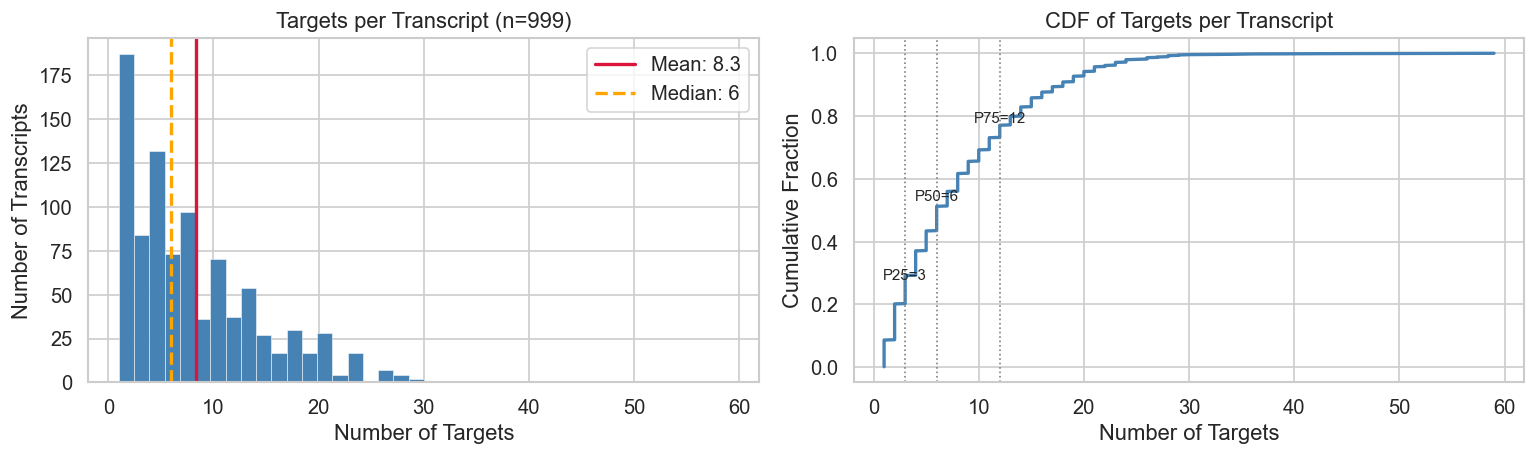


Targets per transcript — summary:
count    929.000000
mean       8.292788
std        6.721873
min        1.000000
25%        3.000000
50%        6.000000
75%       12.000000
max       59.000000
dtype: float64


In [15]:
# Build DataFrame and compute normalized_text column
import numpy as np  # re-bind: an earlier cell may have used `np` as a loop variable (e.g. noun_chunks)

full_targets_df = pd.DataFrame(all_targets_full)

if len(full_targets_df) > 0:
    # Add normalized target text for MT computation
    print("Normalizing target text...")
    full_targets_df['normalized_text'] = [
        extractor.normalize_target(txt)
        for txt in tqdm(full_targets_df['target_text'].tolist(), desc='Normalizing', unit='target')
    ]

    # Targets per transcript distribution (force int64 so plots never see object dtypes)
    targets_per_tid = full_targets_df.groupby('transcriptid').size()
    tid_counts = targets_per_tid.astype("int64").to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram of targets per transcript
    axes[0].hist(tid_counts, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0].axvline(targets_per_tid.mean(), color='crimson', lw=2,
                    label=f'Mean: {targets_per_tid.mean():.1f}')
    axes[0].axvline(targets_per_tid.median(), color='orange', lw=2, linestyle='--',
                    label=f'Median: {targets_per_tid.median():.0f}')
    axes[0].set_title(f'Targets per Transcript (n={len(run_tids):,})')
    axes[0].set_xlabel('Number of Targets')
    axes[0].set_ylabel('Number of Transcripts')
    axes[0].legend()

    # Cumulative distribution
    sorted_counts = np.sort(tid_counts)
    cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
    axes[1].plot(sorted_counts, cdf, color='steelblue', lw=2)
    for q, label in [(0.25, 'P25'), (0.50, 'P50'), (0.75, 'P75')]:
        val = np.quantile(sorted_counts, q)
        axes[1].axvline(val, color='gray', lw=1, linestyle=':')
        axes[1].text(val, q + 0.03, f'{label}={val:.0f}', ha='center', fontsize=9)
    axes[1].set_title('CDF of Targets per Transcript')
    axes[1].set_xlabel('Number of Targets')
    axes[1].set_ylabel('Cumulative Fraction')

    plt.tight_layout()
    plt.show()

    print("\nTargets per transcript — summary:")
    print(targets_per_tid.describe())
else:
    print("No targets extracted — check input data.")

---
## Section 7 — Moving Targets Computation

### The MT Formula

$$\text{MT}_{i,t} = \frac{|T_{i,t-4} \setminus T_{i,t}|}{|T_{i,t-4}|}$$

Where:
- $T_{i,t}$ = set of normalized performance targets mentioned by firm $i$ in quarter $t$
- $T_{i,t-4}$ = set of targets mentioned **four quarters ago** (same fiscal quarter, prior year)
- $T_{i,t-4} \setminus T_{i,t}$ = targets that were in $T_{i,t-4}$ but are **no longer** in $T_{i,t}$ ("dropped targets")

The four-quarter lag (rather than one-quarter) controls for seasonality in how managers talk about goals.

**MT = 0** → firm mentions all the same targets it did a year ago (high accountability)  
**MT = 1** → firm has dropped *every single target* from a year ago (low accountability)

In [16]:
# Demonstrate MT computation manually on a single company
# We need fiscal quarter information — from transcripts_metadata.parquet (best) or CIQ columns

import os

_metadata_candidates = []
_ev = os.environ.get("EARNINGSLENS_RAW", "").strip()
if _ev:
    _ro = Path(_ev).expanduser().resolve()
    _metadata_candidates.extend(
        [
            _ro / "transcripts_metadata.parquet",
            _ro / "ciq_transcript_metadata.parquet",
        ]
    )
_metadata_candidates.extend(
    [
        RAW_DIR / "transcripts_metadata.parquet",
        PROJECT_ROOT.parent / "EarningsLens" / "data" / "raw" / "transcripts_metadata.parquet",
        PROJECT_ROOT.parent / "EarningsLens" / "data" / "raw" / "ciq_transcript_metadata.parquet",
    ]
)

meta_path = next((p for p in _metadata_candidates if p.exists()), None)


def _synthetic_fiscal_from_tid():
    all_tids_list = full_targets_df["transcriptid"].unique()
    quarters = [(2020 + i // 4, (i % 4) + 1) for i in range(len(all_tids_list))]
    tid_to_q = {tid: q for tid, q in zip(all_tids_list, quarters)}
    full_targets_df["companyid"] = full_targets_df["transcriptid"].astype(str).str[-4:]
    full_targets_df["fiscalyear"] = full_targets_df["transcriptid"].map(
        lambda t: tid_to_q.get(t, (2020, 1))[0]
    )
    full_targets_df["fiscalquarter"] = full_targets_df["transcriptid"].map(
        lambda t: tid_to_q.get(t, (2020, 1))[1]
    )


if meta_path is not None:
    meta_df = pd.read_parquet(meta_path)
    meta_sub = meta_df[
        ["transcriptid", "companyid", "companyname", "fiscalyear", "fiscalquarter"]
    ].drop_duplicates(subset=["transcriptid"])
    full_targets_df = full_targets_df.merge(meta_sub, on="transcriptid", how="left")
    print(f"Merged metadata from {meta_path.name}. Columns: {list(full_targets_df.columns)}")
elif (
    "components_df" in globals()
    and components_df is not None
    and len(components_df) > 0
):
    _cols = [
        c
        for c in (
            "transcriptid",
            "companyid",
            "companyname",
            "call_date",
            "event_date",
            "transcriptcreationdate",
            "fiscalyear",
            "fiscalquarter",
        )
        if c in components_df.columns
    ]
    tx = components_df[_cols].drop_duplicates(subset=["transcriptid"])
    if "call_date" not in tx.columns:
        for _dalt in ("event_date", "transcriptcreationdate"):
            if _dalt in tx.columns:
                tx = tx.assign(call_date=tx[_dalt])
                break
    _meta_cols = [
        c
        for c in (
            "transcriptid",
            "companyid",
            "companyname",
            "fiscalyear",
            "fiscalquarter",
        )
        if c in tx.columns
    ]
    if (
        "fiscalyear" in tx.columns
        and "fiscalquarter" in tx.columns
        and tx["fiscalyear"].notna().any()
    ):
        full_targets_df = full_targets_df.merge(tx[_meta_cols], on="transcriptid", how="left")
        print("Merged fiscalyear / fiscalquarter from components_df (CIQ export).")
    elif "call_date" in tx.columns:
        _cd = pd.to_datetime(tx["call_date"], errors="coerce")
        tx = tx.assign(fiscalyear=_cd.dt.year, fiscalquarter=_cd.dt.quarter)
        _merge_cols = [
            c
            for c in (
                "transcriptid",
                "companyid",
                "companyname",
                "fiscalyear",
                "fiscalquarter",
            )
            if c in tx.columns
        ]
        full_targets_df = full_targets_df.merge(tx[_merge_cols], on="transcriptid", how="left")
        print(
            "Merged calendar year & quarter from call_date in components_df. "
            "(True fiscal periods: add transcripts_metadata.parquet from notebook 01.)"
        )
    else:
        _have = [c for c in ("call_date", "event_date", "fiscalyear") if c in components_df.columns]
        print(
            "No transcripts_metadata.parquet and no usable date column in components "
            f"(expected call_date or event_date; have: {_have or 'none'}) — using synthetic fiscal quarters."
        )
        _synthetic_fiscal_from_tid()
else:
    print("No metadata file and no components_df — using synthetic fiscal quarters.")
    _synthetic_fiscal_from_tid()

Merged calendar year & quarter from call_date in components_df. (True fiscal periods: add transcripts_metadata.parquet from notebook 01.)


In [17]:
# Show target sets for one company across multiple quarters
# to build intuition for the MT formula before computing it at scale

# Find a company with data in multiple quarters
if 'companyid' in full_targets_df.columns:
    company_quarter_counts = (
        full_targets_df.groupby('companyid')['fiscalyear']
        .nunique()
        .sort_values(ascending=False)
    )
    demo_company = company_quarter_counts.index[0] if len(company_quarter_counts) > 0 else None

    if demo_company:
        company_df = full_targets_df[full_targets_df['companyid'] == demo_company].copy()
        company_name_demo = company_df.get('companyname', pd.Series(['DEMO'])).iloc[0]

        print(f"Company: {company_name_demo} (id={demo_company})")
        print(f"Quarters with data: {sorted(company_df[['fiscalyear','fiscalquarter']].drop_duplicates().values.tolist())}")
        print()

        for (fy, fq), grp in company_df.groupby(['fiscalyear', 'fiscalquarter']):
            target_set = set(grp['normalized_text'].dropna().str.lower().tolist())
            print(f"  {fy}Q{fq}: {len(target_set)} unique normalized targets")
            for t in sorted(target_set)[:5]:  # show first 5
                print(f"    - {t}")
            if len(target_set) > 5:
                print(f"    ... and {len(target_set)-5} more")
    else:
        print("No multi-quarter company found in sample. Run on more transcripts.")

Company: Ross Stores, Inc. (id=33926.0)
Quarters with data: [[2010, 1], [2010, 2], [2010, 3], [2010, 4], [2011, 1], [2011, 2], [2011, 3], [2011, 4], [2012, 1], [2012, 2], [2012, 3], [2012, 4], [2013, 1], [2013, 2], [2013, 3], [2013, 4], [2014, 1], [2014, 2], [2014, 3], [2014, 4], [2015, 1], [2015, 2], [2015, 3], [2015, 4], [2016, 1], [2016, 2], [2016, 4], [2017, 1], [2017, 2], [2017, 3], [2017, 4], [2018, 1], [2018, 2], [2018, 3], [2018, 4], [2019, 1], [2019, 2], [2019, 3], [2019, 4], [2020, 1], [2020, 2], [2020, 3], [2020, 4], [2021, 1], [2021, 2], [2021, 3], [2021, 4], [2022, 1], [2022, 2], [2022, 3], [2022, 4], [2023, 1], [2023, 2], [2023, 3], [2023, 4]]

  2010Q1: 27 unique normalized targets
    - 1 % to 2 % increase
    - 10.1 %
    - 11.7 %
    - 2 % to 3 %
    - 20 basis point reduction
    ... and 22 more
  2010Q2: 15 unique normalized targets
    - 10 % comparable store sale gain
    - 10.2 % to 10.4 %
    - 12.1 %
    - 2 % to 3 %
    - 230 basis point increase
    ... and 1

In [18]:
# Manual MT computation for the demo company
# Shows exactly what MovingTargetsComputer does under the hood

if demo_company and 'fiscalyear' in full_targets_df.columns:
    company_df = full_targets_df[full_targets_df['companyid'] == demo_company]

    # Build target sets per quarter
    company_target_sets = {}
    for (fy, fq), grp in company_df.groupby(['fiscalyear', 'fiscalquarter']):
        qkey = _quarter_key(int(fy), int(fq))
        company_target_sets[qkey] = grp['normalized_text'].dropna().str.lower().tolist()

    # Manual MT for each quarter that has a t-4 observation
    print(f"Manual MT computation for company {demo_company}:")
    print("=" * 70)

    quarter_keys_sorted = sorted(company_target_sets.keys())
    for qkey in quarter_keys_sorted:
        fy, fq = _parse_quarter_key(qkey)
        # Four quarters ago
        lag_fy, lag_fq = (fy - 1, fq)  # same quarter last year
        lag_key = _quarter_key(lag_fy, lag_fq)

        if lag_key not in company_target_sets:
            print(f"  {qkey}: no t-4 data (need {lag_key}) — skipped")
            continue

        T_t   = set(company_target_sets[qkey])
        T_tm4 = set(company_target_sets[lag_key])

        dropped = T_tm4 - T_t      # in t-4 but NOT in t
        added   = T_t - T_tm4      # in t but NOT in t-4
        retained = T_tm4 & T_t     # in both

        mt = len(dropped) / len(T_tm4) if len(T_tm4) > 0 else float('nan')

        print(f"\n  Quarter: {qkey}  (comparing against {lag_key})")
        print(f"    |T_t|   = {len(T_t)}  (current targets)")
        print(f"    |T_t-4| = {len(T_tm4)}  (prior year targets)")
        print(f"    |Dropped| = {len(dropped)}")
        print(f"    |Added|   = {len(added)}")
        print(f"    MT score  = {mt:.3f}")
        if dropped:
            print(f"    Dropped:  {list(dropped)[:3]}")
else:
    print("Need multi-quarter company data for manual demonstration.")

Manual MT computation for company 33926.0:
  2010Q1: no t-4 data (need 2009Q1) — skipped
  2010Q2: no t-4 data (need 2009Q2) — skipped
  2010Q3: no t-4 data (need 2009Q3) — skipped
  2010Q4: no t-4 data (need 2009Q4) — skipped

  Quarter: 2011Q1  (comparing against 2010Q1)
    |T_t|   = 21  (current targets)
    |T_t-4| = 27  (prior year targets)
    |Dropped| = 26
    |Added|   = 20
    MT score  = 0.963
    Dropped:  ['260 basis point', 'approximately 500 store', '10.1 %']

  Quarter: 2011Q2  (comparing against 2010Q2)
    |T_t|   = 18  (current targets)
    |T_t-4| = 15  (prior year targets)
    |Dropped| = 15
    |Added|   = 18
    MT score  = 1.000
    Dropped:  ['10 % comparable store sale gain', '3 % gain', '3 % reduction']

  Quarter: 2011Q3  (comparing against 2010Q3)
    |T_t|   = 7  (current targets)
    |T_t-4| = 19  (prior year targets)
    |Dropped| = 19
    |Added|   = 7
    MT score  = 1.000
    Dropped:  ['260 - basis - point improvement', '4 % comparable store sale ga

In [19]:
# Run MovingTargetsComputer on the full extracted target set
# Build the input dict format: {(company_id, quarter_key): [target_dicts]}

if 'companyid' in full_targets_df.columns and 'fiscalyear' in full_targets_df.columns:
    target_sets_dict = {}

    for (cid, fy, fq), grp in full_targets_df.groupby(['companyid', 'fiscalyear', 'fiscalquarter']):
        qkey = _quarter_key(int(fy), int(fq))
        target_sets_dict[(str(cid), qkey)] = grp[['target_text', 'normalized_text',
                                                    'is_financial', 'entity_label']].to_dict('records')

    print(f"Target set dict built: {len(target_sets_dict):,} (company, quarter) pairs")
    print(f"Unique companies: {len(set(k[0] for k in target_sets_dict.keys())):,}")

    computer = MovingTargetsComputer(persistence_window=12)
    mt_df = computer.compute_mt(target_sets_dict)

    print(f"\nMT DataFrame shape: {mt_df.shape}")
    print(f"(This contains only rows with valid t-4 data, so it is smaller than the target_sets_dict.)")
    display(mt_df.head())
else:
    print("Missing companyid or fiscal quarter columns — check metadata merge above.")
    mt_df = pd.DataFrame()  # empty fallback

Target set dict built: 929 (company, quarter) pairs
Unique companies: 26

MT DataFrame shape: (778, 10)
(This contains only rows with valid t-4 data, so it is smaller than the target_sets_dict.)


,company_id,quarter_key,fiscal_year,fiscal_quarter,mt_score,n_targets_t,n_targets_t_lag4,n_dropped,financial_drop_ratio,nonfinancial_drop_ratio
0,33926.0,2011Q1,2011,1,0.962963,21,27,26,0.538462,0.461538
1,33926.0,2011Q2,2011,2,1.000000,18,15,15,0.666667,0.333333
2,33926.0,2011Q3,2011,3,1.000000,7,19,19,0.578947,0.421053
3,33926.0,2011Q4,2011,4,1.000000,1,22,22,0.681818,0.318182
4,33926.0,2012Q1,2012,1,0.761905,24,21,16,0.312500,0.687500


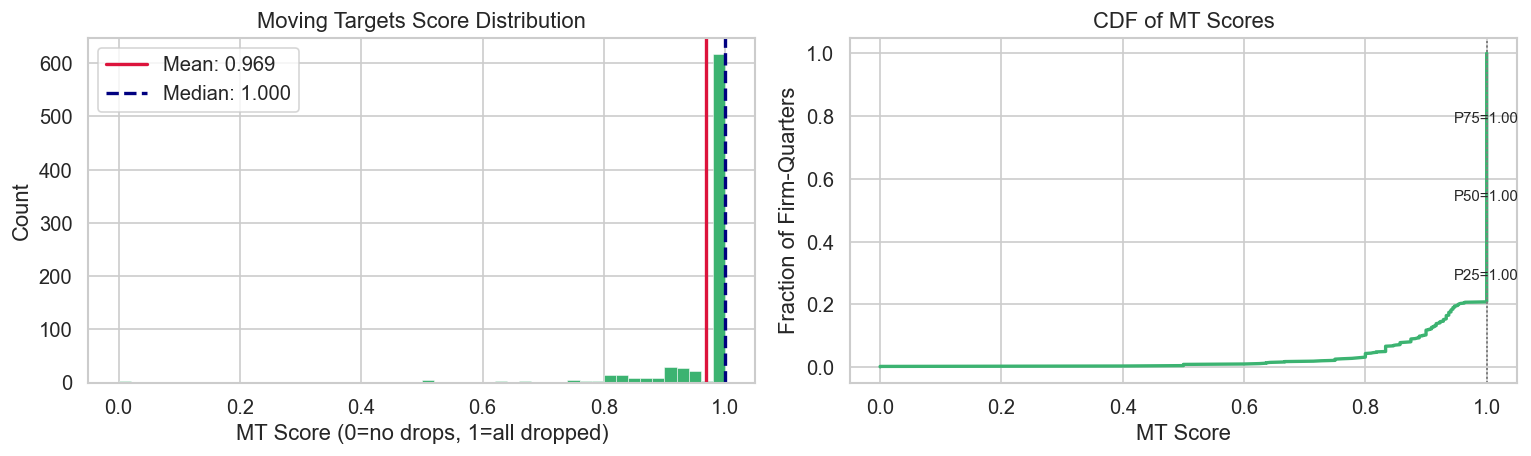


MT score summary statistics:
count    778.000000
mean       0.969157
std        0.087593
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: mt_score, dtype: float64

Firm-quarters with MT = 0 (no drops):   2  (0.3%)
Firm-quarters with MT = 1 (all dropped): 617  (79.3%)


In [20]:
# MT score distribution
if len(mt_df) > 0 and 'mt_score' in mt_df.columns:
    mt_valid = mt_df['mt_score'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram
    axes[0].hist(mt_valid, bins=50, color='mediumseagreen', edgecolor='white', linewidth=0.3)
    axes[0].axvline(mt_valid.mean(), color='crimson', lw=2,
                    label=f'Mean: {mt_valid.mean():.3f}')
    axes[0].axvline(mt_valid.median(), color='navy', lw=2, linestyle='--',
                    label=f'Median: {mt_valid.median():.3f}')
    axes[0].set_title('Moving Targets Score Distribution')
    axes[0].set_xlabel('MT Score (0=no drops, 1=all dropped)')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # CDF
    sorted_mt = np.sort(mt_valid)
    cdf_mt = np.arange(1, len(sorted_mt)+1) / len(sorted_mt)
    axes[1].plot(sorted_mt, cdf_mt, color='mediumseagreen', lw=2)
    for q in [0.25, 0.50, 0.75]:
        val = np.quantile(sorted_mt, q)
        axes[1].axvline(val, color='gray', lw=1, linestyle=':')
        axes[1].text(val, q + 0.03, f'P{int(q*100)}={val:.2f}', ha='center', fontsize=9)
    axes[1].set_title('CDF of MT Scores')
    axes[1].set_xlabel('MT Score')
    axes[1].set_ylabel('Fraction of Firm-Quarters')

    plt.tight_layout()
    plt.show()

    print("\nMT score summary statistics:")
    print(mt_valid.describe())
    print(f"\nFirm-quarters with MT = 0 (no drops):   {(mt_valid == 0).sum():,}  "
          f"({(mt_valid == 0).mean():.1%})")
    print(f"Firm-quarters with MT = 1 (all dropped): {(mt_valid == 1).sum():,}  "
          f"({(mt_valid == 1).mean():.1%})")
else:
    print("No MT scores available — run the extraction and MT computation above.")

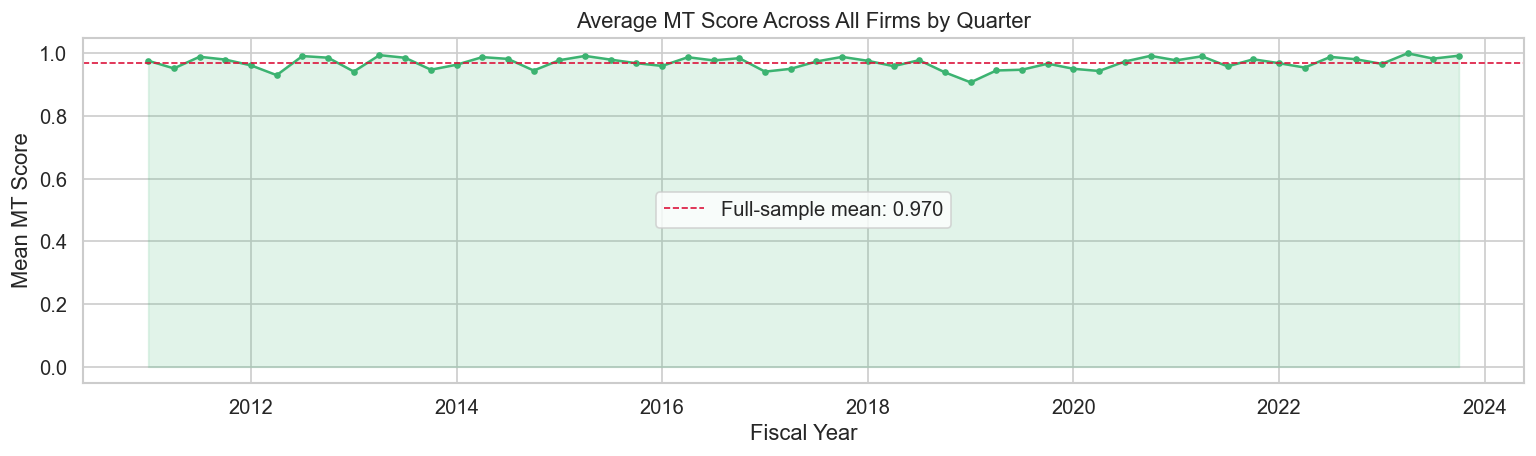

In [21]:
# Time series of average MT score across all firms
# Interesting question: does aggregate MT vary over business cycles?

if len(mt_df) > 0 and 'mt_score' in mt_df.columns and 'fiscal_year' in mt_df.columns:
    mt_ts = (
        mt_df.groupby(['fiscal_year', 'fiscal_quarter'])['mt_score']
        .mean()
        .reset_index()
    )
    mt_ts['quarter_int'] = mt_ts['fiscal_year'] + (mt_ts['fiscal_quarter'] - 1) / 4
    mt_ts = mt_ts.sort_values('quarter_int')

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(mt_ts['quarter_int'], mt_ts['mt_score'], color='mediumseagreen', lw=1.5, marker='o', ms=3)
    ax.fill_between(mt_ts['quarter_int'], mt_ts['mt_score'], alpha=0.15, color='mediumseagreen')
    ax.axhline(mt_ts['mt_score'].mean(), color='crimson', lw=1, linestyle='--',
               label=f'Full-sample mean: {mt_ts["mt_score"].mean():.3f}')
    ax.set_title('Average MT Score Across All Firms by Quarter')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('Mean MT Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(NOTEBOOKS_DIR / 'nb02_mt_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for time series. Need multiple fiscal years.")

---
## Section 8 — Persistence Analysis

A target is **persistent** if it appears in *all* of the prior `persistence_window` quarters (default: 12). The idea: a target that has been mentioned consistently for 3 years is a deeply embedded commitment. Dropping it is more meaningful than dropping a recently introduced target.

The paper uses this to identify a subset of MT — *persistent target drops* — which have even stronger return predictability.

In [22]:
# Demonstrate persistence check for the demo company

if demo_company and 'target_sets_dict' in dir():
    company_targets_demo = {
        qk: tgts
        for (cid, qk), tgts in target_sets_dict.items()
        if cid == str(demo_company)
    }
    available_quarters = sorted(company_targets_demo.keys())

    if available_quarters:
        latest_qkey = available_quarters[-1]
        persistence = computer.compute_persistence(company_targets_demo, latest_qkey)

        print(f"Persistence check for company {demo_company}, reference quarter {latest_qkey}")
        print(f"Persistence window: {computer.persistence_window} quarters")
        print(f"Quarters with data in lookback: "
              f"{[q for q in available_quarters if q < latest_qkey][-12:]}")
        print()

        if persistence:
            persistent = {k: v for k, v in persistence.items() if v}
            non_persistent = {k: v for k, v in persistence.items() if not v}
            print(f"Persistent targets ({len(persistent)} — present in ALL lookback quarters):")
            for tgt in list(persistent.keys())[:5]:
                print(f"  ✓ {tgt!r}")
            print(f"\nNon-persistent targets ({len(non_persistent)} — not in all quarters):")
            for tgt in list(non_persistent.keys())[:5]:
                print(f"  ✗ {tgt!r}")
        else:
            print("No targets found in lookback window (need more historical data).")
    else:
        print("No quarters available for demo company.")
else:
    print("Need target_sets_dict and a demo company — run Sections 6 and 7 first.")

Persistence check for company 33926.0, reference quarter 2023Q4
Persistence window: 12 quarters
Quarters with data in lookback: ['2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3']

Persistent targets (0 — present in ALL lookback quarters):

Non-persistent targets (14 — not in all quarters):
  ✗ '260 basis point'
  ✗ '11.2 %'
  ✗ '3 % to 4 % comp'
  ✗ '11.3 % to 11.5 %'
  ✗ 'estimate $ 260 million benefit'


Unique (company, target) pairs: 5,686


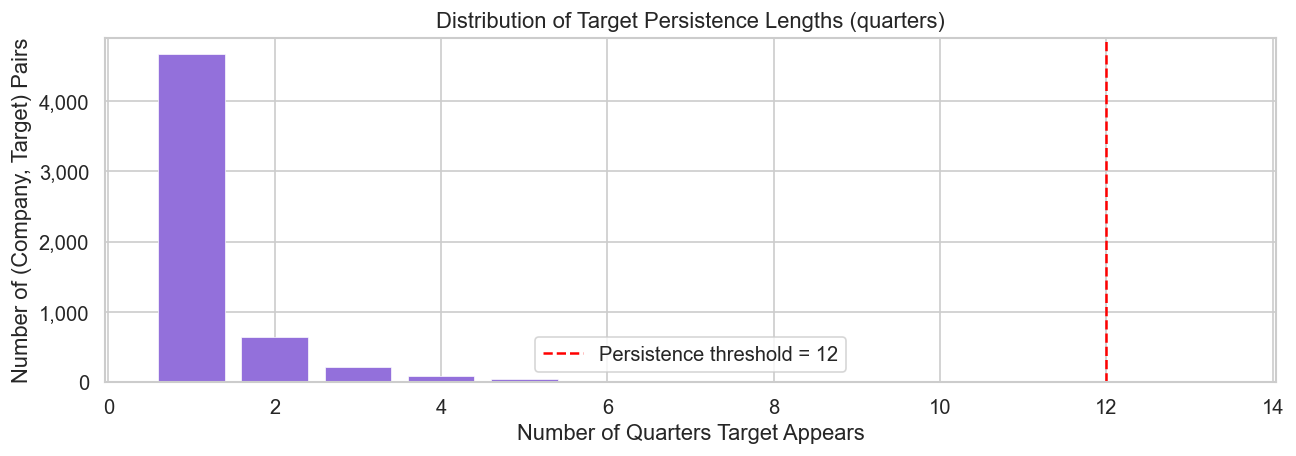


% of (company, target) pairs with span ≥ 12 quarters: 0.0%
Median span: 1 quarters


In [23]:
# Distribution of target persistence lengths
# For each unique target in the corpus, how many consecutive quarters was it present?

if 'target_sets_dict' in dir() and len(target_sets_dict) > 0:
    # For each (company, target), count how many quarters it appears
    company_target_spans = {}

    for (cid, qkey), tgts in target_sets_dict.items():
        for t in tgts:
            norm = t.get('normalized_text', t.get('target_text', '')).lower().strip()
            if norm:
                key = (cid, norm)
                company_target_spans.setdefault(key, set()).add(qkey)

    span_lengths = [len(qs) for qs in company_target_spans.values()]

    print(f"Unique (company, target) pairs: {len(span_lengths):,}")

    fig, ax = plt.subplots(figsize=(11, 4))
    max_span = min(max(span_lengths) if span_lengths else 20, 20)
    span_dist = pd.Series(span_lengths).value_counts().sort_index()
    ax.bar(span_dist.index[:max_span], span_dist.values[:max_span],
           color='mediumpurple', edgecolor='white', linewidth=0.4)
    ax.axvline(12, color='red', lw=1.5, linestyle='--', label='Persistence threshold = 12')
    ax.set_title('Distribution of Target Persistence Lengths (quarters)')
    ax.set_xlabel('Number of Quarters Target Appears')
    ax.set_ylabel('Number of (Company, Target) Pairs')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

    pct_persistent = sum(1 for s in span_lengths if s >= 12) / len(span_lengths)
    print(f"\n% of (company, target) pairs with span ≥ 12 quarters: {pct_persistent:.1%}")
    print(f"Median span: {pd.Series(span_lengths).median():.0f} quarters")
else:
    print("No target_sets_dict available — run extraction first.")

---
## Section 9 — Financial vs. Non-Financial Analysis

Cohen & Nguyen (2024) distinguish between **financial target drops** (MONEY or PERCENT entities) and **non-financial target drops** (PRODUCT, CARDINAL, QUANTITY). Their key finding:

> *Non-financial target drops predict future stock underperformance more strongly than financial drops.*

Intuition: when a company quietly stops mentioning its operational or strategic goals (headcount targets, product launch timelines, customer growth goals), the market takes longer to notice than when they drop an EPS or margin target.

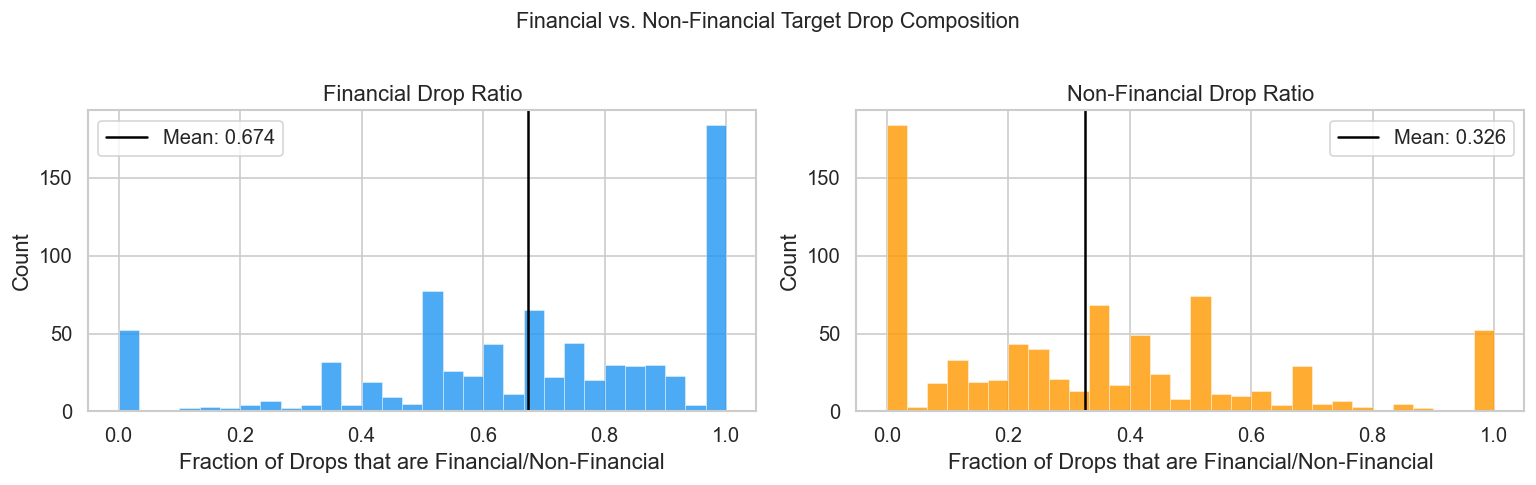


Financial drop ratio summary:
count    776.000000
mean       0.673735
std        0.282684
min        0.000000
25%        0.500000
50%        0.692308
75%        0.916667
max        1.000000
Name: financial_drop_ratio, dtype: float64

Non-financial drop ratio summary:
count    776.000000
mean       0.326265
std        0.282684
min        0.000000
25%        0.083333
50%        0.307692
75%        0.500000
max        1.000000
Name: nonfinancial_drop_ratio, dtype: float64

Mean MT score when drops are mostly financial:     0.971 (n=631)
Mean MT score when drops are mostly non-financial: 0.977 (n=216)


In [24]:
# Compute financial_drop_ratio and nonfinancial_drop_ratio from MT DataFrame

if len(mt_df) > 0 and 'financial_drop_ratio' in mt_df.columns:
    fin_dr_valid = mt_df['financial_drop_ratio'].dropna()
    nfin_dr_valid = mt_df['nonfinancial_drop_ratio'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, series, label, color in [
        (axes[0], fin_dr_valid, 'Financial Drop Ratio', '#2196F3'),
        (axes[1], nfin_dr_valid, 'Non-Financial Drop Ratio', '#FF9800'),
    ]:
        ax.hist(series, bins=30, color=color, edgecolor='white', linewidth=0.3, alpha=0.8)
        ax.axvline(series.mean(), color='black', lw=1.5,
                   label=f'Mean: {series.mean():.3f}')
        ax.set_title(label)
        ax.set_xlabel('Fraction of Drops that are Financial/Non-Financial')
        ax.set_ylabel('Count')
        ax.legend()

    plt.suptitle('Financial vs. Non-Financial Target Drop Composition', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nFinancial drop ratio summary:")
    print(fin_dr_valid.describe())
    print("\nNon-financial drop ratio summary:")
    print(nfin_dr_valid.describe())

    # Compare MT scores for high-financial-drop vs high-nonfinancial-drop firms
    mt_df_valid = mt_df.dropna(subset=['mt_score', 'financial_drop_ratio', 'nonfinancial_drop_ratio'])
    if len(mt_df_valid) > 10:
        high_fin  = mt_df_valid[mt_df_valid['financial_drop_ratio'] >= 0.5]['mt_score']
        high_nfin = mt_df_valid[mt_df_valid['nonfinancial_drop_ratio'] >= 0.5]['mt_score']
        print(f"\nMean MT score when drops are mostly financial:     {high_fin.mean():.3f} (n={len(high_fin)})")
        print(f"Mean MT score when drops are mostly non-financial: {high_nfin.mean():.3f} (n={len(high_nfin)})")
else:
    print("financial_drop_ratio column not available. Check that target dicts include 'is_financial'.")

---
## Section 10 — Manual Spot-Check

Always spot-check extraction quality before trusting any downstream analysis. Pick a handful of random transcripts and manually inspect whether the extracted targets look reasonable.

**What to look for:**
- Are the targets plausible forward-looking commitments?
- Are there false positives (e.g., backward-looking statements captured)?
- Are there obvious false negatives (targets in the text that were missed)?

**Common failure modes of the spaCy baseline:**
- Misses implicit targets (*"we're aiming for double-digit growth"* — "double-digit" is not tagged `NUM`)
- Captures analyst questions as targets if they contain goal-verb syntax
- Splits compound entities incorrectly (*"$2-3 billion"* may capture only *"$2"*)

In [25]:
# Spot-check: pick 5 random transcripts and show original text + extracted targets side by side

random.seed(42)
available_tids_full = full_targets_df['transcriptid'].unique().tolist()
spot_check_tids = random.sample(
    available_tids_full,
    min(5, len(available_tids_full))
)

print("=" * 80)
print("MANUAL SPOT-CHECK — 5 Random Transcripts")
print("Use this section to manually verify extraction quality.")
print("=" * 80)

for spot_tid in spot_check_tids:
    spot_targets = full_targets_df[full_targets_df['transcriptid'] == spot_tid]

    # Get company info
    company_info = ''
    if 'companyname' in spot_targets.columns:
        company_info = spot_targets['companyname'].iloc[0] if len(spot_targets) > 0 else ''
    fy = spot_targets['fiscalyear'].iloc[0] if 'fiscalyear' in spot_targets.columns and len(spot_targets) > 0 else '?'
    fq = spot_targets['fiscalquarter'].iloc[0] if 'fiscalquarter' in spot_targets.columns and len(spot_targets) > 0 else '?'

    print(f"\n─── Transcript {spot_tid} | {company_info} | {fy}Q{fq} ─────────────────")
    print(f"Extracted {len(spot_targets)} targets:")

    for i, (_, trow) in enumerate(spot_targets.head(5).iterrows()):
        fin_flag = '[FIN]' if trow.get('is_financial') else '[non-fin]'
        verb = trow.get('governing_verb', '?')
        norm = trow.get('normalized_text', trow.get('target_text', '?'))
        sentence = str(trow.get('sentence', ''))[:100]
        print(f"  {i+1}. {fin_flag} verb={verb!r:10s} target={norm!r}")
        print(f"     context: {sentence}...")
    if len(spot_targets) > 5:
        print(f"  ... and {len(spot_targets)-5} more targets")

MANUAL SPOT-CHECK — 5 Random Transcripts
Use this section to manually verify extraction quality.

─── Transcript 1592070.0 | Ribbon Communications Inc. | 2018Q4 ─────────────────
Extracted 7 targets:
  1. [non-fin] verb='expect'   target='roughly 20 large former genband sbc customer'
     context: We expect roughly 20 large former GENBAND SBC customers to transition to Ribbon portfolio in a relat...
  2. [non-fin] verb='expect'   target='more than half'
     context: We expect roughly 20 large former GENBAND SBC customers to transition to Ribbon portfolio in a relat...
  3. [non-fin] verb='plan'     target='ribbon sbc 7000 product'
     context: This former GENBAND customer also plans to deploy our Ribbon SBC 7000 product, illustrating our cros...
  4. [FIN] verb='reach'    target='5 %'
     context: We don't expect it to reach a material level in the very near term, which we would judge being 5% of...
  5. [FIN] verb='deliver'  target='3 %'
     context: Therefore, Ribbon's business e

### What to look for in the spot-check above

**Signs of good extraction:**
- Target text contains a quantified commitment (%, $, or specific number)
- The governing verb is genuinely forward-looking ("expect", "target", "deliver")
- The source sentence reads like a management statement, not analyst question

**Signs of potential issues:**
- Very short targets like *"15 percent"* without the associated noun phrase — this is a noun chunk boundary issue
- Analyst questions captured (component_type = 3 targets should be reviewed carefully)
- Historical statements like *"we achieved 15% growth last year"* incorrectly included

These issues motivate the LLM-based extraction approach in Notebook 03, which can reason about temporal context and speaker intent.

---
## Section 11 — Save Results

In [28]:
# Save spacy_targets.parquet — one row per extracted target
if len(full_targets_df) > 0:
    targets_out_path = PROCESSED_DIR / 'spacy_targets.parquet'
    full_targets_df.to_parquet(targets_out_path, index=False)
    print(f"Saved spacy_targets.parquet → {targets_out_path}")
    print(f"  Shape: {full_targets_df.shape}")
    print(f"  Columns: {list(full_targets_df.columns)}")
else:
    print("No targets to save.")

Saved spacy_targets.parquet → /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/spacy_targets.parquet
  Shape: (7704, 13)
  Columns: ['target_text', 'entity_label', 'numeric_value', 'governing_verb', 'is_financial', 'sentence', 'component_type', 'transcriptid', 'normalized_text', 'companyid', 'companyname', 'fiscalyear', 'fiscalquarter']


In [29]:
# Save spacy_mt_scores.parquet — one row per (company, quarter) with MT score
if len(mt_df) > 0:
    mt_out_path = PROCESSED_DIR / 'spacy_mt_scores.parquet'
    mt_df.to_parquet(mt_out_path, index=False)
    print(f"Saved spacy_mt_scores.parquet → {mt_out_path}")
    print(f"  Shape: {mt_df.shape}")
    print(f"  Columns: {list(mt_df.columns)}")
    print(f"\n  MT score stats:")
    print(f"    Mean:   {mt_df['mt_score'].mean():.4f}")
    print(f"    Std:    {mt_df['mt_score'].std():.4f}")
    print(f"    Median: {mt_df['mt_score'].median():.4f}")
else:
    print("No MT scores to save — run Section 7 first.")

Saved spacy_mt_scores.parquet → /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/spacy_mt_scores.parquet
  Shape: (778, 10)
  Columns: ['company_id', 'quarter_key', 'fiscal_year', 'fiscal_quarter', 'mt_score', 'n_targets_t', 'n_targets_t_lag4', 'n_dropped', 'financial_drop_ratio', 'nonfinancial_drop_ratio']

  MT score stats:
    Mean:   0.9692
    Std:    0.0876
    Median: 1.0000


In [30]:
# Final summary
print("=" * 60)
print("  NOTEBOOK 02 COMPLETE — SUMMARY")
print("=" * 60)

summary_items = [
    ("Transcripts processed",          f"{len(run_tids):,}"),
    ("Total targets extracted",        f"{len(full_targets_df):,}"),
    ("Unique normalized targets",
     f"{full_targets_df['normalized_text'].nunique():,}" if len(full_targets_df) > 0 else 'N/A'),
    ("Mean targets per transcript",
     f"{len(full_targets_df)/len(run_tids):.1f}" if len(run_tids) > 0 else 'N/A'),
    ("MT score rows (with t-4 data)",  f"{len(mt_df):,}"),
    ("Mean MT score",
     f"{mt_df['mt_score'].mean():.4f}" if len(mt_df) > 0 and 'mt_score' in mt_df else 'N/A'),
]

for label, val in summary_items:
    print(f"  {label:40s}  {val}")

print("\nFiles saved:")
for p in [PROCESSED_DIR / 'spacy_targets.parquet', PROCESSED_DIR / 'spacy_mt_scores.parquet']:
    exists = "✓" if p.exists() else "✗ (not saved)"
    print(f"  {exists}  {p}")

print("\nNext step → 03_llm_extraction.ipynb")

  NOTEBOOK 02 COMPLETE — SUMMARY
  Transcripts processed                     999
  Total targets extracted                   7,704
  Unique normalized targets                 4,128
  Mean targets per transcript               7.7
  MT score rows (with t-4 data)             778
  Mean MT score                             0.9692

Files saved:
  ✓  /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/spacy_targets.parquet
  ✓  /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/spacy_mt_scores.parquet

Next step → 03_llm_extraction.ipynb
